# Visión Computacional Basada en Redes Neuronales Artificiales
## Grupo 3 - Trabajo Práctico Especial

Integrantes del grupo:

* Joaquín Sebastián Tschopp
* Santiago Bezchinsky





# 0 Importaciones de librerías

In [1]:
%pip install torchview


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Librerías de PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
import torchvision.transforms.v2 as T

# Extras
import numpy as np
import pandas as pd
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
import os
from os import path
from datetime import datetime
from enum import Enum
from dataclasses import dataclass
import textwrap
import inspect
import json
import uuid

import torch
import torch.nn as nn

import torchvision
from torchview import draw_graph

## 0.1 Configuración del ambiente para Colab (Esto no lo toque)

In [3]:
# montamos la unidad de Google Drive
"""
from google.colab import drive
drive.mount('/content/gdrive/')

# carpeta donde van a guardar los datos
from os import makedirs
datasets_folder = '/content/gdrive/My Drive/Colab Notebooks/Computer Vision/Grupo 3'
makedirs(datasets_folder, exist_ok=True)

# NO TOCAR EL CÓDIGO DE ACÁ ABAJO, ES PARA BAJAR DATOS NUEVOS!
new_datasets_folder = '/content/gdrive/My Drive/Colab Notebooks/Computer Vision/'
makedirs(new_datasets_folder, exist_ok=True)
!rm /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/cifar10.1_v4_data.npy*
!rm /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/cifar10.1_v4_labels.npy*
!wget --no-check-certificate -P /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_data.npy
!wget --no-check-certificate -P /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_labels.npy
!ls /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/

results_folder = '/content/gdrive/My Drive/Maestría/VCBRNA/Resultados'
"""

<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
/var/folders/66/98ml0k7s50sbjln7zqxcj2y80000gn/T/ipykernel_96387/3094113058.py:14: SyntaxWarning: invalid escape sequence '\ '
  !rm /content/gdrive/My\ Drive/Colab\ Notebooks/Computer\ Vision/cifar10.1_v4_data.npy*


"\nfrom google.colab import drive\ndrive.mount('/content/gdrive/')\n\n# carpeta donde van a guardar los datos\nfrom os import makedirs\ndatasets_folder = '/content/gdrive/My Drive/Colab Notebooks/Computer Vision/Grupo 3'\nmakedirs(datasets_folder, exist_ok=True)\n\n# NO TOCAR EL CÓDIGO DE ACÁ ABAJO, ES PARA BAJAR DATOS NUEVOS!\nnew_datasets_folder = '/content/gdrive/My Drive/Colab Notebooks/Computer Vision/'\nmakedirs(new_datasets_folder, exist_ok=True)\n!rm /content/gdrive/My\\ Drive/Colab\\ Notebooks/Computer\\ Vision/cifar10.1_v4_data.npy*\n!rm /content/gdrive/My\\ Drive/Colab\\ Notebooks/Computer\\ Vision/cifar10.1_v4_labels.npy*\n!wget --no-check-certificate -P /content/gdrive/My\\ Drive/Colab\\ Notebooks/Computer\\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_data.npy\n!wget --no-check-certificate -P /content/gdrive/My\\ Drive/Colab\\ Notebooks/Computer\\ Vision/ https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_lab

## 0.2 Carga de Datos en Local!!! (:rocket)

In [4]:
# Configuración de carpetas para uso local
from os import makedirs, path
import urllib.request
import os

# Carpeta local donde van a guardar los datos
datasets_folder = 'datasets/Grupo_3'
makedirs(datasets_folder, exist_ok=True)
# Carpeta para datos nuevos (CIFAR10.1)
new_datasets_folder = 'datasets/Grupo_3'
makedirs(new_datasets_folder, exist_ok=True)

# Carpeta local para resultados (misma que el script en ppio)
results_folder = './Resultados'
makedirs(results_folder, exist_ok=True)

# Rutas de los archivos
data_file = path.join(new_datasets_folder, 'cifar10.1_v4_data.npy')
labels_file = path.join(new_datasets_folder, 'cifar10.1_v4_labels.npy')

# URLs de descarga
data_url = 'https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_data.npy'
labels_url = 'https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v4_labels.npy'

# Descargar archivos si no existen
def download_file(url, filename):
    if not path.exists(filename):
        print(f"Descargando {filename}...")
        urllib.request.urlretrieve(url, filename)
        print(f"✓ {filename} descargado")
    else:
        print(f"✓ {filename} ya existe")

download_file(data_url, data_file)
download_file(labels_url, labels_file)

# Listar archivos en la carpeta
print(f"\nArchivos en {new_datasets_folder}:")
for item in os.listdir(new_datasets_folder):
    item_path = path.join(new_datasets_folder, item)
    if path.isfile(item_path):
        size_mb = path.getsize(item_path) / (1024 * 1024)
        print(f"  - {item} ({size_mb:.2f} MB)")
    else:
        print(f"  - {item}/ (directorio)")

Descargando datasets/Grupo_3/cifar10.1_v4_data.npy...
✓ datasets/Grupo_3/cifar10.1_v4_data.npy descargado
Descargando datasets/Grupo_3/cifar10.1_v4_labels.npy...
✓ datasets/Grupo_3/cifar10.1_v4_labels.npy descargado

Archivos en datasets/Grupo_3:
  - cifar10.1_v4_data.npy (5.92 MB)
  - cifar10.1_v4_labels.npy (0.01 MB)


# 1 Arquitectura del Modelo y Pipeline de Entrenamiento

Esto es una **arquitectura orientada a objetos** con la clase `TrainingPipeline` que encapsula todo el flujo de trabajo:

## 1.1 Arquitecturas

### CNN Simple

3 bloques conv, sin dropout

In [5]:
class SimpleCNN(nn.Module):
    """
    CNN básica con 3 bloques convolucionales

    Arquitectura:
    - 3 bloques Conv -> ReLU -> MaxPool
    - 2 capas fully connected
    """

    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Bloque 1: 3 -> 32 canales
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16

        # Bloque 2: 32 -> 64 canales
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8

        # Bloque 3: 64 -> 128 canales
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4

        # Fully connected
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

        # Activación final
        self.final_activation = nn.Softmax(dim=1)

    def forward(self, x):
        # Bloque 1
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Bloque 2
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Bloque 3
        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        # Flatten
        x = x.view(-1, 128 * 4 * 4)

        # FC
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def predict(self, x):
        return self.final_activation(self.forward(x))

### CNN Mejorada

Agrega capas convolucionales (total de 5)
Incluye BatchNorm en cada capa
Agrega Dropout al final para ayudar al overfitting

In [6]:
class ImprovedCNN(nn.Module):
    """
    CNN con Batch Normalization y arquitectura más profunda

    Arquitectura:
    - 5 bloques Conv -> BatchNorm -> ReLU -> MaxPool
    - 2 capas fully connected con BatchNorm
    - Dropout para regularización
    """

    def __init__(self):
        super(ImprovedCNN, self).__init__()

        # Bloque 1: 3 -> 64 canales
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        # Bloque 2: 64 -> 128 canales
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16

        # Bloque 3: 128 -> 256 canales
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        # Bloque 4: 256 -> 256 canales
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8

        # Bloque 5: 256 -> 512 canales
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4

        # Fully connected con BatchNorm
        self.fc1 = nn.Linear(512 * 4 * 4, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 10)

        # Regularización
        self.dropout = nn.Dropout(0.5)

        # Activación final
        self.final_activation = nn.Softmax(dim=1)

    def forward(self, x):
        # Bloque 1
        x = F.relu(self.bn1(self.conv1(x)))

        # Bloque 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.dropout(x)

        # Bloque 3
        x = F.relu(self.bn3(self.conv3(x)))

        # Bloque 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)
        x = self.dropout(x)

        # Bloque 5
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool5(x)
        x = self.dropout(x)

        # Flatten
        x = x.view(-1, 512 * 4 * 4)

        # FC con BatchNorm y Dropout
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

    def predict(self, x):
        return self.final_activation(self.forward(x))

### ResNet

Red mas profunda con skip connections

In [7]:
class ResidualBlock(nn.Module):
    """Bloque residual básico con skip connection"""

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection con ajuste de dimensión
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Skip connection
        out += self.shortcut(identity)
        out = F.relu(out)

        return out


class ResNetCIFAR(nn.Module):
    """
    ResNet adaptado para CIFAR-10 con skip connections

    Arquitectura:
    - Capa inicial convolucional
    - 3 grupos de bloques residuales
    - Global Average Pooling
    - Fully connected final

    """

    def __init__(self, num_blocks=[2, 2, 2]):
        super(ResNetCIFAR, self).__init__()

        # Capa inicial
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Grupos de bloques residuales
        self.layer1 = self._make_layer(64, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks[2], stride=2)

        # Clasificador
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 10)

        # Activación final
        self.final_activation = nn.Softmax(dim=1)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []

        # Primer bloque puede cambiar dimensiones
        layers.append(ResidualBlock(in_channels, out_channels, stride))

        # Bloques subsecuentes mantienen dimensiones
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Capa inicial
        x = F.relu(self.bn1(self.conv1(x)))

        # Bloques residuales
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Global Average Pooling
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)

        # Clasificador
        x = self.fc(x)

        return x

    def predict(self, x):
        return self.final_activation(self.forward(x))

### Resnet Deep

In [8]:
class BottleneckBlock(nn.Module):
    """Bloque residual con bottleneck"""

    def __init__(self, in_channels, out_channels, stride=1):
        super(BottleneckBlock, self).__init__()
        self.conv1 = nn.Conv2d()

class ResNetDeep(nn.Module):
    """
    ResNet con mayor profundidad (50 capas) con skip connections

    Arquitectura:
    - Capa inicial convolucional
    - 3 grupos de bloques residuales
    - Global Average Pooling
    - Fully connected final

    """

    def __init__(self, num_blocks=[2, 2, 2]):
        super(ResNetCIFAR, self).__init__()

        # Capa inicial
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Grupos de bloques residuales
        self.layer1 = self._make_layer(64, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks[2], stride=2)

        # Clasificador
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 10)

        # Activación final
        self.final_activation = nn.Softmax(dim=1)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []

        # Primer bloque puede cambiar dimensiones
        layers.append(ResidualBlock(in_channels, out_channels, stride))

        # Bloques subsecuentes mantienen dimensiones
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Capa inicial
        x = F.relu(self.bn1(self.conv1(x)))

        # Bloques residuales
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Global Average Pooling
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)

        # Clasificador
        x = self.fc(x)

        return x

    def predict(self, x):
        return self.final_activation(self.forward(x))

### RED LOCA NAS-CNN

Exploracion de paper e idas probadas que rapidamente quedan desactualizadas. Evidancia de una busqueda cientifica de como mejorar nuestras predicciones, siempre imporntate entender el contexto de las arquitecturas y sus pruebas.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ==============================================================================
# NAS-CNN v1 (Zoph & Le, 2017) - 15 capas sin stride ni pooling
# ==============================================================================
class NASCNN15(nn.Module):
    """
    Reimplementación aproximada de la arquitectura de 15 capas para CIFAR-10
    (NAS v1, sin stride ni pooling, Figura 7 del paper).

    - Bloque por capa: Conv2d (bias=False) -> BatchNorm -> ReLU.
    - Resolución fija 32×32 (stride=1). El padding se elige para conservar tamaño:
      padding = ((FH-1)//2, (FW-1)//2) en kernels impares (incluye casos asimétricos).
    - Las capas con múltiples predecesoras concatenan sus entradas por el eje de canales.
    - Clasificador: Global Average Pooling (1×1) + Linear (con bias) → logits.
      Softmax solo en .predict() (para entrenamiento usar CrossEntropyLoss sobre logits).

    Detalle por capa (FH = filter height, FW = filter width, N = #filtros), tal cual Figura 7:
      C1 : FH=3, FW=3, N=36      ; in = imagen RGB
      C2 : FH=3, FW=3, N=48      ; in = C1
      C3 : FH=3, FW=3, N=36      ; in = concat(C1, C2)
      C4 : FH=5, FW=5, N=36      ; in = concat(C1, C2, C3)
      C5 : FH=3, FW=7, N=48      ; in = concat(C3, C4)
      C6 : FH=7, FW=7, N=48      ; in = concat(C2, C3, C4, C5)
      C7 : FH=7, FW=7, N=48      ; in = concat(C2, C3, C4, C5, C6)
      C8 : FH=7, FW=3, N=36      ; in = concat(C1, C6, C7)
      C9 : FH=7, FW=1, N=36      ; in = concat(C1, C5, C6, C8)
      C10: FH=7, FW=7, N=36      ; in = concat(C1, C3, C4, C5, C6, C7, C8, C9)
      C11: FH=5, FW=7, N=36      ; in = concat(C1, C2, C5, C6, C7, C8, C9, C10)
      C12: FH=7, FW=7, N=48      ; in = concat(C1, C2, C3, C4, C6, C11)
      C13: FH=7, FW=5, N=48      ; in = concat(C1, C3, C6, C7, C8, C9, C10, C11, C12)
      C14: FH=7, FW=5, N=48      ; in = concat(C3, C7, C12, C13)
      C15: FH=7, FW=5, N=48      ; in = concat(C6, C7, C11, C12, C13, C14)

    Entrenamiento (setup fiel al paper NAS v1 para CIFAR-10):
      - Optimizador: SGD con Nesterov, lr inicial 0.1, momentum 0.9, weight decay 1e-4.
      - Pérdida: nn.CrossEntropyLoss (sin label smoothing).
      - Épocas: ~200–300 con scheduler que reduce lr.
      - Augment básico recomendado (flip horizontal, crop con padding).
    """


    def __init__(self, num_classes: int = 10):
        super().__init__()

        # N (out_channels) por capa según Figura 7:
        # 1:36, 2:48, 3:36, 4:36, 5:48, 6:48, 7:48, 8:36, 9:36,
        # 10:36, 11:36, 12:48, 13:48, 14:48, 15:48

        # C1: in=3,   out=36, k=3x3
        self.conv1 = nn.Conv2d(3, 36, kernel_size=(3,3), padding=(1,1), bias=False)
        self.bn1   = nn.BatchNorm2d(36)

        # C2: in=36,  out=48, k=3x3
        self.conv2 = nn.Conv2d(36, 48, kernel_size=(3,3), padding=(1,1), bias=False)
        self.bn2   = nn.BatchNorm2d(48)

        # C3: in=[x1(36), x2(48)] = 84,  out=36, k=3x3
        self.conv3 = nn.Conv2d(84, 36, kernel_size=(3,3), padding=(1,1), bias=False)
        self.bn3   = nn.BatchNorm2d(36)

        # C4: in=[x1(36), x2(48), x3(36)] = 120, out=36, k=5x5
        self.conv4 = nn.Conv2d(120, 36, kernel_size=(5,5), padding=(2,2), bias=False)
        self.bn4   = nn.BatchNorm2d(36)

        # C5: in=[x3(36), x4(36)] = 72,  out=48, k=3x7
        self.conv5 = nn.Conv2d(72, 48, kernel_size=(3,7), padding=(1,3), bias=False)
        self.bn5   = nn.BatchNorm2d(48)

        # C6: in=[x2(48), x3(36), x4(36), x5(48)] = 168, out=48, k=7x7
        self.conv6 = nn.Conv2d(168, 48, kernel_size=(7,7), padding=(3,3), bias=False)
        self.bn6   = nn.BatchNorm2d(48)

        # C7: in=[x2(48), x3(36), x4(36), x5(48), x6(48)] = 216, out=48, k=7x7
        self.conv7 = nn.Conv2d(216, 48, kernel_size=(7,7), padding=(3,3), bias=False)
        self.bn7   = nn.BatchNorm2d(48)

        # C8: in=[x1(36), x6(48), x7(48)] = 132, out=36, k=7x3
        self.conv8 = nn.Conv2d(132, 36, kernel_size=(7,3), padding=(3,1), bias=False)
        self.bn8   = nn.BatchNorm2d(36)

        # C9: in=[x1(36), x5(48), x6(48), x8(36)] = 168, out=36, k=7x1
        self.conv9 = nn.Conv2d(168, 36, kernel_size=(7,1), padding=(3,0), bias=False)
        self.bn9   = nn.BatchNorm2d(36)

        # C10: in=[x1(36), x3(36), x4(36), x5(48), x6(48), x7(48), x8(36), x9(36)] = 324,
        #      out=36, k=7x7
        self.conv10 = nn.Conv2d(324, 36, kernel_size=(7,7), padding=(3,3), bias=False)
        self.bn10   = nn.BatchNorm2d(36)

        # C11: in=[x1(36), x2(48), x5(48), x6(48), x7(48), x8(36), x9(36), x10(36)] = 336,
        #      out=36, k=5x7
        self.conv11 = nn.Conv2d(336, 36, kernel_size=(5,7), padding=(2,3), bias=False)
        self.bn11   = nn.BatchNorm2d(36)

        # C12: in=[x1(36), x2(48), x3(36), x4(36), x6(48), x11(36)] = 240,
        #      out=48, k=7x7
        self.conv12 = nn.Conv2d(240, 48, kernel_size=(7,7), padding=(3,3), bias=False)
        self.bn12   = nn.BatchNorm2d(48)

        # C13: in=[x1(36), x3(36), x6(48), x7(48), x8(36), x9(36), x10(36), x11(36), x12(48)] = 360,
        #      out=48, k=7x5
        self.conv13 = nn.Conv2d(360, 48, kernel_size=(7,5), padding=(3,2), bias=False)
        self.bn13   = nn.BatchNorm2d(48)

        # C14: in=[x3(36), x7(48), x12(48), x13(48)] = 180,
        #      out=48, k=7x5
        self.conv14 = nn.Conv2d(180, 48, kernel_size=(7,5), padding=(3,2), bias=False)
        self.bn14   = nn.BatchNorm2d(48)

        # C15: in=[x6(48), x7(48), x11(36), x12(48), x13(48), x14(48)] = 276,
        #      out=48, k=7x5
        self.conv15 = nn.Conv2d(276, 48, kernel_size=(7,5), padding=(3,2), bias=False)
        self.bn15   = nn.BatchNorm2d(48)

        # Clasificador: GAP + FC (logits). FC con bias (no hay BN después).
        self.fc = nn.Linear(48, num_classes)

        # Softmax sólo para .predict()
        self.final_activation = nn.Softmax(dim=1)

    def forward(self, x):
        # C1, C2
        x1 = F.relu(self.bn1(self.conv1(x)))         # [B, 36, 32, 32]
        x2 = F.relu(self.bn2(self.conv2(x1)))        # [B, 48, 32, 32]

        # C3
        x3_in = torch.cat([x1, x2], dim=1)
        x3 = F.relu(self.bn3(self.conv3(x3_in)))     # [B, 36, 32, 32]

        # C4
        x4_in = torch.cat([x1, x2, x3], dim=1)
        x4 = F.relu(self.bn4(self.conv4(x4_in)))     # [B, 36, 32, 32]

        # C5
        x5_in = torch.cat([x3, x4], dim=1)
        x5 = F.relu(self.bn5(self.conv5(x5_in)))     # [B, 48, 32, 32]

        # C6
        x6_in = torch.cat([x2, x3, x4, x5], dim=1)
        x6 = F.relu(self.bn6(self.conv6(x6_in)))     # [B, 48, 32, 32]

        # C7
        x7_in = torch.cat([x2, x3, x4, x5, x6], dim=1)
        x7 = F.relu(self.bn7(self.conv7(x7_in)))     # [B, 48, 32, 32]

        # C8
        x8_in = torch.cat([x1, x6, x7], dim=1)
        x8 = F.relu(self.bn8(self.conv8(x8_in)))     # [B, 36, 32, 32]

        # C9
        x9_in = torch.cat([x1, x5, x6, x8], dim=1)
        x9 = F.relu(self.bn9(self.conv9(x9_in)))     # [B, 36, 32, 32]

        # C10
        x10_in = torch.cat([x1, x3, x4, x5, x6, x7, x8, x9], dim=1)
        x10 = F.relu(self.bn10(self.conv10(x10_in))) # [B, 36, 32, 32]

        # C11
        x11_in = torch.cat([x1, x2, x5, x6, x7, x8, x9, x10], dim=1)
        x11 = F.relu(self.bn11(self.conv11(x11_in))) # [B, 36, 32, 32]

        # C12
        x12_in = torch.cat([x1, x2, x3, x4, x6, x11], dim=1)
        x12 = F.relu(self.bn12(self.conv12(x12_in))) # [B, 48, 32, 32]

        # C13
        x13_in = torch.cat([x1, x3, x6, x7, x8, x9, x10, x11, x12], dim=1)
        x13 = F.relu(self.bn13(self.conv13(x13_in))) # [B, 48, 32, 32]

        # C14
        x14_in = torch.cat([x3, x7, x12, x13], dim=1)
        x14 = F.relu(self.bn14(self.conv14(x14_in))) # [B, 48, 32, 32]

        # C15
        x15_in = torch.cat([x6, x7, x11, x12, x13, x14], dim=1)
        x15 = F.relu(self.bn15(self.conv15(x15_in))) # [B, 48, 32, 32]

        # Clasificador
        out = F.adaptive_avg_pool2d(x15, output_size=1)  # [B, 48, 1, 1]
        out = out.view(out.size(0), -1)                  # [B, 48]
        out = self.fc(out)                               # [B, num_classes] (logits)
        return out

    def predict(self, x):
        logits = self.forward(x)
        return self.final_activation(logits)


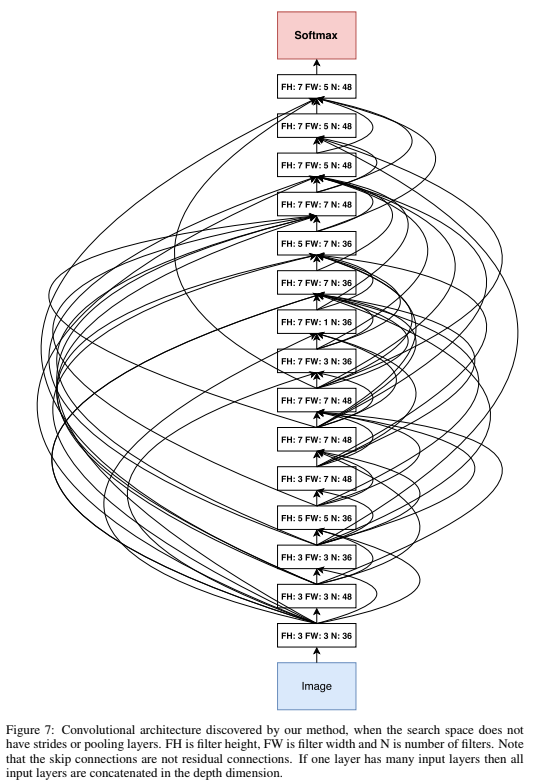

### Comparación de arquitecturas

In [10]:
# ==============================================================================
# FUNCIÓN AUXILIAR: Comparar arquitecturas
# ==============================================================================
def compare_models():
    """Compara las 4 arquitecturas disponibles"""
    models = {
        'CNN Simple (BASELINE)': SimpleCNN(),
        'CNN Mejorada': ImprovedCNN(),
        'ResNetCIFAR': ResNetCIFAR()
    }

    print("="*70)
    print("COMPARACIÓN DE ARQUITECTURAS")
    print("="*70)

    for name, model in models.items():
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\n{name}")
        print(f"  Parámetros totales: {total_params:,}")
        print(f"  Parámetros entrenables: {trainable_params:,}")

        # Calcular tamaño en MB
        param_size = total_params * 4 / (1024**2)  # 4 bytes por parámetro (float32)
        print(f"  Tamaño estimado: {param_size:.2f} MB")

## Imagen de la red!!!!

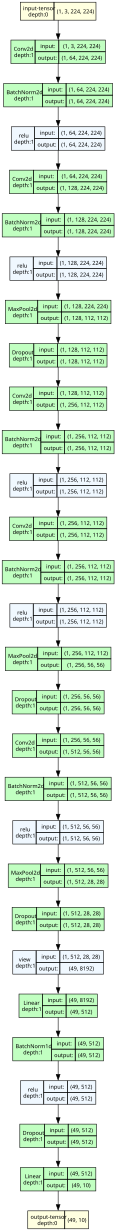

In [11]:
model_graph = draw_graph(ImprovedCNN(), input_size=(1,3,224,224), expand_nested=True)
model_graph.visual_graph

## 1.2 Pipeline de Entrenamiento

In [12]:
# ==============================================================================
# PIPELINE DE ENTRENAMIENTO
# ==============================================================================

class TrainingPipeline:
    """
    Pipeline completo de entrenamiento, validación y evaluación
    Incluye:
    - Detección automática de device (CUDA/MPS/CPU)
    - Entrenamiento con early stopping
    - Sistema de checkpoints
    - Evaluación y métricas
    - Visualizaciones
    - Guardado de configuraciones y resultados
    """

    def __init__(self, model, config):
        """
        Args:
            model: Modelo de PyTorch (nn.Module)
            config: Dict con configuración (lr, epochs, batch_size, patience, etc.)
        """
        # Detección automática de device
        self.device = self._detect_device()
        print(f"Device detectado: {self.device}")

        # Modelo y configuración
        self.model = model.to(self.device)
        self.config = config

        # Optimizador
        optimizer_type = config.get('optimizer', 'SGD')
        opt_class = getattr(optim, optimizer_type)
        params = inspect.signature(opt_class.__init__).parameters
        opt_kwargs = {"lr": config["lr"]}

        for key, value in config.items():
            if key in params:
                opt_kwargs[key] = value

        self.optimizer = opt_class(self.model.parameters(), **opt_kwargs)

        # Mantenemos solo esta loss por las clases y el label smoothing para pruebas
        self.loss_function = nn.CrossEntropyLoss(
            #https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
            label_smoothing=0.05 # Por defecto es 0.0
        ).to(self.device)

        # LR Scheduler (con plateau)
        es_patience = self.config.get('es_patience', 10)
        lr_patience = self.config.get('lr_patience', 3)

        if lr_patience > es_patience: # Advertir si el patiencie esta mal configurado
            print(f"Warning: lr_patience ({lr_patience}) > early_stopping_patience ({es_patience})")

        self.lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, patience=lr_patience, factor=0.5, min_lr=1e-6
        ) if self.config['lr_scheduler'] else None

        #Opcionals de LR Scheduler
        # self.lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        #     self.optimizer, T_max=es_patience, eta_min=1e-5
        # ) if self.config['lr_scheduler'] else None


        # Estado del entrenamiento
        self.train_losses = []
        self.val_losses = []
        self.val_metrics = []
        self.best_val_acc = 0.0
        self.best_epoch = 0
        self.current_epoch = 0

        # Directorio del experimento
        self.experiment_id = str(uuid.uuid4())
        self.experiment_name = config.get("experiment_name", "experimento_sin_nombre")
        self.experiment_dir = os.path.join(
            config.get('base_dir', '.'),
            f"{self.experiment_name}_{self.experiment_id}"
        )
        os.makedirs(self.experiment_dir, exist_ok=True)

        # Directorio de resultados
        self.results_dir = os.path.join(self.experiment_dir, 'results')
        os.makedirs(self.results_dir, exist_ok=True)

        # Directorio de checkpoints
        self.checkpoint_dir = os.path.join(self.experiment_dir, 'checkpoints')
        os.makedirs(self.checkpoint_dir, exist_ok=True)

        # Archivo de log de experimentos (JSON Lines), general
        self.experiments_log_path = os.path.join(
            config.get('base_dir', '.'),
            config.get("experiments_log_file", "experiments_log.jsonl")
        )

    def _detect_device(self):
        """Detecta el mejor dispositivo disponible"""
        if torch.cuda.is_available():
            return torch.device('cuda')  # NVIDIA GPU
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            return torch.device('mps')   # Apple Silicon (M1/M2/M3)
        else:
            return torch.device('cpu')   # CPU fallback

    def _train_epoch(self, train_loader):
        """Entrena una época completa"""
        self.model.train()
        running_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.loss_function(output, target)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * data.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        return epoch_loss

    def _validate_epoch(self, val_loader):
        """Valida una época completa"""
        self.model.eval()
        running_loss = 0.0
        correct = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                loss = self.loss_function(output, target)
                running_loss += loss.item() * data.size(0)

                probs = self.model.final_activation(output)
                preds = probs.argmax(dim=1)
                correct += (preds == target).sum().item()

        epoch_loss = running_loss / len(val_loader.dataset)
        epoch_acc = correct / len(val_loader.dataset)
        return epoch_loss, epoch_acc

    def train(self, train_loader, val_loader):
        """
        Entrenamiento completo con early stopping y checkpoints

        Args:
            train_loader: DataLoader de entrenamiento
            val_loader: DataLoader de validación
        """
        print("\n" + "="*70)
        print("ENTRENAMIENTO DEL MODELO")
        print("="*70)
        print(f"Épocas: {self.config['epochs']}")
        print(f"Batch size: {self.config['batch_size']}")
        print(f"Learning rate: {self.config['lr']}")
        print(f"Device: {self.device}")
        print(f"Early stopping patience: {self.config['es_patience']}")
        print("="*70 + "\n")

        patience_counter = 0

        try:
            for epoch in range(1, self.config['epochs'] + 1):
                self.current_epoch = epoch

                # Entrenar
                train_loss = self._train_epoch(train_loader)
                self.train_losses.append(train_loss)

                # Validar
                val_loss, val_acc = self._validate_epoch(val_loader)
                self.val_losses.append(val_loss)
                self.val_metrics.append(val_acc)

                if self.lr_scheduler is not None:
                    if isinstance(self.lr_scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                        self.lr_scheduler.step(val_loss)
                    else:
                        # Otros schedulers (StepLR, Cosine, etc.) no necesitan métrica
                        self.lr_scheduler.step()

                # Logging
                print(f"Epoch {epoch:02d} | "
                      f"Current LR: {self.optimizer.param_groups[0]['lr']:.2e} | "
                      f"Train Loss: {train_loss:.4f} | "
                      f"Val Loss: {val_loss:.4f} | "
                      f"Val Acc: {val_acc:.2%}",
                      end="")

                # Guardar mejor modelo
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_epoch = epoch
                    patience_counter = 0
                    self.save_checkpoint('best_model.pth', is_best=True)
                    print(" ✓ MEJOR", end="")
                else:
                    patience_counter += 1

                print()

                # Checkpoint periódico
                if epoch % 5 == 0:
                    self.save_checkpoint('last_checkpoint.pth')
                    print(f"  → Checkpoint guardado")

                # Early stopping
                if patience_counter >= self.config['es_patience']:
                    print(f"\n! Early stopping en época {epoch}")
                    print(f"  No hubo mejora en {self.config['es_patience']} épocas")
                    print(f"  Mejor accuracy: {self.best_val_acc:.2%} (época {self.best_epoch})")
                    break

        except KeyboardInterrupt:
            print("\n" + "="*70)
            print("! ENTRENAMIENTO INTERRUMPIDO")
            print("="*70)
            self.save_checkpoint('interrupted_checkpoint.pth')
            print(f"Estado guardado en: {self.checkpoint_dir}interrupted_checkpoint.pth")
            print("="*70)

        # Resumen final
        print("\n" + "="*70)
        print("RESUMEN DEL ENTRENAMIENTO")
        print("="*70)
        print(f"Épocas completadas: {len(self.train_losses)}")
        print(f"Mejor accuracy de validación: {self.best_val_acc:.2%} (época {self.best_epoch})")
        print(f"Accuracy final: {self.val_metrics[-1]:.2%}")
        print("="*70)

        # Cargar mejor modelo
        self.load_checkpoint('best_model.pth')
        print(f"\n✓ Mejor modelo cargado automáticamente")

    def save_checkpoint(self, filename, is_best=False):
        """Guarda checkpoint del estado actual"""
        filepath = os.path.join(self.checkpoint_dir, filename)
        checkpoint = {
            'epoch': self.current_epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'lr_scheduler_state_dict': self.lr_scheduler.state_dict() if self.lr_scheduler is not None else None,
            'best_val_acc': self.best_val_acc,
            'best_epoch': self.best_epoch,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'val_metrics': self.val_metrics,
            'config': self.config
        }
        torch.save(checkpoint, filepath)

    def load_checkpoint(self, filename):
        """Carga checkpoint desde archivo"""
        filepath = os.path.join(self.checkpoint_dir, filename)
        if not os.path.exists(filepath):
            print(f"! Checkpoint no encontrado: {filepath}")
            return False

        checkpoint = torch.load(filepath, map_location=self.device, weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if self.lr_scheduler is not None:
            self.lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
        self.current_epoch = checkpoint['epoch']
        self.best_val_acc = checkpoint['best_val_acc']
        self.best_epoch = checkpoint['best_epoch']
        self.train_losses = checkpoint['train_losses']
        self.val_losses = checkpoint['val_losses']
        self.val_metrics = checkpoint['val_metrics']

        print(f"✓ Checkpoint cargado: {filename}")
        print(f"  Época: {self.current_epoch}, Acc: {self.best_val_acc:.2%}")
        return True

    def resume_training(self, checkpoint_file, train_loader, val_loader):
        """Reanuda entrenamiento desde checkpoint"""
        if not self.load_checkpoint(checkpoint_file):
            print("No se puede reanudar el entrenamiento")
            return

        print(f"\nReanudando desde época {self.current_epoch + 1}...")

        # Ajustar configuración para continuar
        remaining_epochs = self.config['epochs'] - self.current_epoch
        if remaining_epochs <= 0:
            print("El entrenamiento ya se completó")
            return

        # Continuar entrenamiento
        original_epochs = self.config['epochs']
        self.train(train_loader, val_loader)

    def evaluate(self, test_loader, dataset_name="Test"):
        """
        Evalúa el modelo en un conjunto de datos

        Args:
            test_loader: DataLoader de test
            dataset_name: Nombre del dataset para logging

        Returns:
            Dict con resultados: accuracy, predictions, labels, probabilities
        """
        print("\n" + "="*70)
        print(f"EVALUACIÓN EN {dataset_name.upper()}")
        print("="*70)

        self.model.eval()
        all_predictions = []
        all_labels = []
        all_probabilities = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)

                output = self.model(data)
                probs = self.model.final_activation(output)
                preds = probs.argmax(dim=1)

                all_predictions.extend(preds.cpu().numpy())
                all_labels.extend(target.cpu().numpy())
                all_probabilities.extend(probs.cpu().numpy())

        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
        all_probabilities = np.array(all_probabilities)

        # Calcular accuracy
        accuracy = (all_predictions == all_labels).sum() / len(all_labels)

        print(f"\nAccuracy en {dataset_name}: {accuracy:.2%}")
        print(f"   Correctas: {(all_predictions == all_labels).sum()}/{len(all_labels)}")
        print("="*70)

        return {
            'accuracy': accuracy,
            'predictions': all_predictions,
            'labels': all_labels,
            'probabilities': all_probabilities
        }

    def register_experiment(
        self,
        train_transforms,
        val_transforms,
        extra_results=None,
        max_model_lines=80,
        max_transforms_lines=100,
        save_markdown=True,
    ):
        """
        Registra el experimento actual en un log (JSONL) y opcionalmente
        genera un resumen en Markdown.

        Args:
            train_transforms, val_transforms:
                Transformaciones (objetos o strings).
            extra_results:
                Dict opcional con métricas adicionales (por ej: test_accuracy,
                f1_score, etc.).
            max_model_lines:
                Máximo de líneas de la arquitectura a guardar.
            max_transforms_lines:
                Máximo de líneas totales de transformaciones.
            save_markdown:
                Si True, guarda un resumen legible en .md
        Returns:
            experiment_record (dict): registro completo guardado en el log.
        """

        # ------------------------------------------------------------------
        # 1) Info de modelo (string recortado)
        # ------------------------------------------------------------------
        model_str = str(self.model)
        model_lines = model_str.splitlines()
        if len(model_lines) > max_model_lines:
            model_lines = model_lines[:max_model_lines] + ["...", "(truncado)"]
        model_str_limited = "\n".join(model_lines)

        # ------------------------------------------------------------------
        # 2) Info de hiperparámetros / optimizer / scheduler
        # ------------------------------------------------------------------
        opt_name = type(self.optimizer).__name__
        opt_state = self.optimizer.state_dict()
        opt_params = opt_state.get('param_groups', [{}])[0]

        optimizer_info = {
            "type": opt_name,
            "params": {
                k: v for k, v in opt_params.items()
                if k in ["lr", "momentum", "weight_decay", "nesterov", "betas", "eps"]
            }
        }

        if self.lr_scheduler is not None:
            sched_name = type(self.lr_scheduler).__name__
            sched_state = self.lr_scheduler.state_dict()
            lr_scheduler_info = {
                "type": sched_name,
                "state": sched_state
            }
        else:
            lr_scheduler_info = None

        # ------------------------------------------------------------------
        # 3) Transformaciones como texto
        # ------------------------------------------------------------------
        def _tf_to_str(name, tf_obj):
            if tf_obj is None:
                return f"{name}: (no especificado)"
            if isinstance(tf_obj, str):
                base = f"{name}:\n{tf_obj}"
            else:
                base = f"{name}:\n{str(tf_obj)}"

            lines = [l for l in base.splitlines()]
            if len(lines) > max_transforms_lines:
                lines = lines[:max_transforms_lines] + ["...", "(truncado)"]
            return "\n".join(lines)

        train_tf_str = _tf_to_str("Train transforms", train_transforms)
        val_tf_str   = _tf_to_str("Validation transforms", val_transforms)

        # ------------------------------------------------------------------
        # 4) Resultados (usando lo que ya tiene el pipeline)
        # ------------------------------------------------------------------
        if len(self.val_metrics) > 0:
            best_val_acc = float(self.best_val_acc)
            final_val_acc = float(self.val_metrics[-1])
        else:
            best_val_acc = None
            final_val_acc = None

        if len(self.val_losses) > 0:
            min_val_loss = float(np.min(self.val_losses))
            final_val_loss = float(self.val_losses[-1])
        else:
            min_val_loss = None
            final_val_loss = None

        results_info = {
            "best_epoch": int(self.best_epoch),
            "best_val_acc": best_val_acc,
            "final_val_acc": final_val_acc,
            "min_val_loss": min_val_loss,
            "final_val_loss": final_val_loss,
            "train_epochs": len(self.train_losses),
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "val_metrics": self.val_metrics
        }

        if extra_results is not None:
            results_info.update(extra_results)

        # ------------------------------------------------------------------
        # 5) Armar registro de experimento
        # ------------------------------------------------------------------
        now = datetime.now()
        timestamp = now.isoformat()

        experiment_record = {
            "id": self.experiment_id,
            "timestamp": timestamp,
            "experiment_name": self.experiment_name,
            "device": str(self.device),
            "model_class": self.model.__class__.__name__,
            "model_repr": model_str_limited,
            "config": dict(self.config),
            "optimizer": optimizer_info,
            "lr_scheduler": lr_scheduler_info,
            "train_transforms": train_tf_str,
            "val_transforms": val_tf_str,
            "results": results_info,
        }

        # ------------------------------------------------------------------
        # 6) Guardar en log JSONL
        # ------------------------------------------------------------------
        with open(self.experiments_log_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(experiment_record, ensure_ascii=False) + "\n")

        print(f"✓ Experimento registrado en: {self.experiments_log_path}")
        print(f"  id={self.experiment_id} | nombre={self.experiment_name}")

        # ------------------------------------------------------------------
        # 7) Resumen Markdown opcional
        # ------------------------------------------------------------------
        if save_markdown:
            md_name = f"{now.strftime('%Y%m%d_%H%M%S')}_{self.experiment_name}.md"
            md_path = os.path.join(self.results_dir, md_name)

            with open(md_path, "w", encoding="utf-8") as f:
                f.write(f"# Resumen de experimento\n\n")
                f.write(f"- **ID**: `{self.experiment_id}`\n")
                f.write(f"- **Nombre**: `{self.experiment_name}`\n")
                f.write(f"- **Fecha**: `{timestamp}`\n")
                f.write(f"- **Device**: `{self.device}`\n\n")

                f.write("## Configuración\n\n")
                for k, v in self.config.items():
                    f.write(f"- **{k}**: `{v}`\n")
                f.write("\n")

                f.write("## Resultados\n\n")
                for k, v in results_info.items():
                    f.write(f"- **{k}**: `{v}`\n")
                f.write("\n")

                f.write("## Optimizer\n\n")
                f.write(f"- Tipo: `{optimizer_info['type']}`\n")
                for k, v in optimizer_info["params"].items():
                    f.write(f"- {k}: `{v}`\n")
                f.write("\n")

                if lr_scheduler_info is not None:
                    f.write("## LR Scheduler\n\n")
                    f.write(f"- Tipo: `{lr_scheduler_info['type']}`\n\n")

                f.write("## Arquitectura del modelo (truncada)\n\n")
                f.write("```text\n")
                f.write(model_str_limited)
                f.write("\n```\n\n")

                f.write("## Transformaciones\n\n")
                f.write("```text\n")
                f.write(train_tf_str)
                f.write("\n\n")
                f.write(val_tf_str)
                f.write("\n```\n")

            print(f"✓ Resumen Markdown guardado en: {md_path}")

        return experiment_record

    def summarize_experiments(self, sort_by="results.best_val_acc", top_k=10):
        """
        Lee el log de experimentos y muestra un resumen tabular básico.

        Args:
            sort_by: clave para ordenar (ej: 'results.best_val_acc').
            top_k: cantidad de filas a mostrar.
        """

        if not os.path.exists(self.experiments_log_path):
            print(f"! No existe log de experimentos en {self.experiments_log_path}")
            return None

        records = []
        with open(self.experiments_log_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                records.append(rec)

        if not records:
            print("! Log vacío")
            return None

        # Aplanar algunas columnas útiles
        flat = []
        for r in records:
            row = {
                "id": r["id"],
                "timestamp": r["timestamp"],
                "name": r.get("experiment_name", ""),
                "device": r.get("device", ""),
                "epochs": r["results"].get("train_epochs"),
                "best_epoch": r["results"].get("best_epoch"),
                "best_val_acc": r["results"].get("best_val_acc"),
                "final_val_acc": r["results"].get("final_val_acc"),
                "min_val_loss": r["results"].get("min_val_loss"),
                "final_val_loss": r["results"].get("final_val_loss"),
                "lr": r["optimizer"]["params"].get("lr"),
                "optimizer": r["optimizer"]["type"],
            }
            flat.append(row)

        df = pd.DataFrame(flat)

        # Ordenar
        if sort_by == "results.best_val_acc":
            df = df.sort_values("best_val_acc", ascending=False)
        elif sort_by == "results.final_val_acc":
            df = df.sort_values("final_val_acc", ascending=False)

        print("\n=== RESUMEN DE EXPERIMENTOS ===")
        print(df.head(top_k).to_string(index=False))
        return df

    def plot_training_curves(self):
        """Genera gráficos de curvas de entrenamiento"""
        sns.set_style("whitegrid")
        sns.set_context("notebook", font_scale=1.2)

        colors = sns.color_palette("husl", 3)

        print("\n" + "="*70)
        print("CURVAS DE APRENDIZAJE")
        print("="*70)
        print(f"Épocas: {len(self.train_losses)}")
        print(f"Mejor accuracy: {max(self.val_metrics):.2%} (época {np.argmax(self.val_metrics)+1})")
        print(f"Overfitting gap: {self.val_losses[-1] - self.train_losses[-1]:.4f}")
        print("="*70)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs = np.arange(1, len(self.train_losses) + 1)

        # Loss
        axes[0].plot(epochs, self.train_losses, color=colors[0], linewidth=2.5,
                    label='Train', alpha=0.8)
        axes[0].plot(epochs, self.val_losses, color=colors[1], linewidth=2.5,
                    label='Validation', alpha=0.8)
        best_epoch = np.argmin(self.val_losses)
        axes[0].scatter(best_epoch + 1, self.val_losses[best_epoch],
                       color='green', s=150, marker='*', zorder=5)
        axes[0].set_xlabel('Época', fontweight='bold')
        axes[0].set_ylabel('Loss', fontweight='bold')
        axes[0].set_title('Evolución de la Loss', fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(epochs, np.array(self.val_metrics) * 100, color=colors[1],
                    linewidth=2.5, alpha=0.8)
        best_acc_epoch = np.argmax(self.val_metrics)
        axes[1].scatter(best_acc_epoch + 1, self.val_metrics[best_acc_epoch] * 100,
                       color='green', s=150, marker='*', zorder=5)
        axes[1].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Baseline')
        axes[1].set_xlabel('Época', fontweight='bold')
        axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
        axes[1].set_title('Evolución del Accuracy', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim(0, 100)

        # Overfitting gap
        gap = np.array(self.val_losses) - np.array(self.train_losses)
        axes[2].plot(epochs, gap, color='purple', linewidth=2.5, alpha=0.8)
        axes[2].fill_between(epochs, 0, gap, color='purple', alpha=0.2)
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        axes[2].set_xlabel('Época', fontweight='bold')
        axes[2].set_ylabel('Gap (Val - Train)', fontweight='bold')
        axes[2].set_title('Medida de Overfitting', fontweight='bold')
        axes[2].grid(True, alpha=0.3)

        if gap[-1] > 0.5:
            axes[2].text(0.5, 0.95, '! OVERFITTING', transform=axes[2].transAxes,
                        fontsize=11, color='red', fontweight='bold', ha='center',
                        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, "training_curves.png"))
        plt.show()



    def plot_confusion_matrix(self, predictions, labels, class_names):
        """Genera matriz de confusión"""
        cm = confusion_matrix(labels, predictions)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel('Predicción', fontweight='bold')
        ax.set_ylabel('Real', fontweight='bold')
        ax.set_title('Matriz de Confusión', fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()


    def plot_examples(self, images, predictions, labels, class_names,
                     mean, std, n_correct=10, n_incorrect=10):
        """Muestra ejemplos de predicciones correctas e incorrectas"""

        def denormalize(img, mean, std):
            img_denorm = img.copy()
            for c in range(3):
                img_denorm[c] = img_denorm[c] * std[c] + mean[c]
            img_denorm = np.clip(img_denorm, 0, 1)
            return np.transpose(img_denorm, (1, 2, 0))

        correct_mask = (predictions == labels)
        correct_idx = np.where(correct_mask)[0]
        incorrect_idx = np.where(~correct_mask)[0]

        # Ejemplos correctos
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        fig.suptitle('Predicciones CORRECTAS', fontsize=16, fontweight='bold')

        sample_correct = np.random.choice(correct_idx,
                                         size=min(n_correct, len(correct_idx)),
                                         replace=False)

        for idx, ax in enumerate(axes.flat):
            if idx < len(sample_correct):
                i = sample_correct[idx]
                img = denormalize(images[i], mean, std)
                ax.imshow(img)
                ax.set_title(f'Real: {class_names[labels[i]]}\n'
                           f'Pred: {class_names[predictions[i]]}',
                           color='green', fontsize=9)
                ax.axis('off')
            else:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

        # Ejemplos incorrectos
        if len(incorrect_idx) > 0:
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            fig.suptitle('Predicciones INCORRECTAS', fontsize=16, fontweight='bold')

            sample_incorrect = np.random.choice(incorrect_idx,
                                               size=min(n_incorrect, len(incorrect_idx)),
                                               replace=False)

            for idx, ax in enumerate(axes.flat):
                if idx < len(sample_incorrect):
                    i = sample_incorrect[idx]
                    img = denormalize(images[i], mean, std)
                    ax.imshow(img)
                    ax.set_title(f'Real: {class_names[labels[i]]}\n'
                               f'Pred: {class_names[predictions[i]]}',
                               color='red', fontsize=9)
                    ax.axis('off')
                else:
                    ax.axis('off')

            plt.tight_layout()
            plt.show()


print("✓ Clase TrainingPipeline cargada exitosamente")

✓ Clase TrainingPipeline cargada exitosamente


## 1.3 Clases de Preprocesamiento

In [13]:
@dataclass
class TransformConfig:
    img_size: int = 32

    # Geométricas básicas
    use_random_resized_crop: bool = False
    use_random_crop_with_padding: bool = False
    crop_padding: int = 4

    use_random_horizontal_flip: bool = False
    random_horizontal_flip_prob: float = 0.5

    use_random_rotation: bool = False
    rotation_degrees: float = 15.0

    # Políticas avanzadas
    use_autoaugment: bool = False
    use_trivial_augment: bool = False

    # Fotométricas simples
    use_color_jitter: bool = False
    jitter_brightness: float = 0.2
    jitter_contrast: float = 0.2
    jitter_saturation: float = 0.2
    jitter_hue: float = 0.1

    # Regularización en imagen
    use_random_erasing: bool = False
    random_erasing_p: float = 0.25

    normalize: bool = True


def compute_dataset_stats(dataset_root: str):
    cifar10_training = datasets.CIFAR10(dataset_root, train=True, download=True)
    data = cifar10_training.data  # (50000, 32, 32, 3), uint8

    mean = np.mean(data, axis=(0, 1, 2)) / 255.0
    std = np.std(data, axis=(0, 1, 2)) / 255.0

    return mean.tolist(), std.tolist()


def build_transforms(mean, std, config: TransformConfig):
    """
    Construye transformaciones usando la nueva API torchvision.transforms.v2.
    Pensado para CIFAR10 (32x32).
    """
    train_transforms = []

    # -------------------------
    # 1) Geométricas iniciales
    # -------------------------
    if config.use_random_resized_crop:
        train_transforms.append(T.RandomResizedCrop(config.img_size))
    elif config.use_random_crop_with_padding:
        train_transforms.append(
            T.RandomCrop(config.img_size, padding=config.crop_padding)
        )
    else:
        train_transforms.append(T.Resize((config.img_size, config.img_size)))

    if config.use_random_horizontal_flip:
        train_transforms.append(
            T.RandomHorizontalFlip(config.random_horizontal_flip_prob)
        )

    if config.use_random_rotation:
        train_transforms.append(
            T.RandomRotation(degrees=config.rotation_degrees)
        )

    # -------------------------
    # 2) Políticas de AutoAugment
    #    (incluyen color jitter, etc.)
    # -------------------------
    if config.use_autoaugment:
        train_transforms.append(
            T.AutoAugment(policy=T.AutoAugmentPolicy.CIFAR10)
        )
    elif config.use_trivial_augment:
        train_transforms.append(T.TrivialAugmentWide())

    # -------------------------
    # 3) Fotométricas simples
    #    (solo si NO usamos una política automática)
    # -------------------------
    if config.use_color_jitter and not (config.use_autoaugment or config.use_trivial_augment):
        train_transforms.append(
            T.ColorJitter(
                brightness=config.jitter_brightness,
                contrast=config.jitter_contrast,
                saturation=config.jitter_saturation,
                hue=config.jitter_hue,
            )
        )

    # -------------------------
    # 4) Conversión a tensor + normalización
    # -------------------------
    train_transforms.extend([
        T.ToImage(),                              # PIL/ndarray -> Tensor (C,H,W)
        T.ToDtype(torch.float32, scale=True),     # Escala a [0,1] y dtype float32
    ])

    if config.normalize:
        train_transforms.append(T.Normalize(mean, std))

    # -------------------------
    # 5) Regularización final
    # -------------------------
    if config.use_random_erasing:
        train_transforms.append(
            T.RandomErasing(p=config.random_erasing_p)
        )

    train_transform = T.Compose(train_transforms)

    # Transformaciones de test: sin augmentations pesadas
    test_transform = T.Compose([
        T.Resize((config.img_size, config.img_size)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean, std) if config.normalize else T.Identity(),
    ])

    return train_transform, test_transform


# 2. Carga y preprocesamiento de los datos

Cargamos los datos de entrenamiento, calculamos media y desvío para normalizar

In [14]:
# ==============================================================================
# VARIANTES DE DATA AUGMENTATION
# ==============================================================================

config_sin_augmentation = TransformConfig() # Por defecto solo normaliza

# Crop+Padding y Horizontal Flip
config_light = TransformConfig(
        img_size=32,
        use_random_resized_crop=False,
        use_random_crop_with_padding=True,
        crop_padding=4,
        use_random_horizontal_flip=True,
        random_horizontal_flip_prob=0.5,
        use_random_rotation=False,
        use_autoaugment=False,
        use_trivial_augment=False,
        use_color_jitter=False,
        use_random_erasing=False,
        normalize=True,
    )

# AutoAugment + RandomErasing
config_autoaugment = TransformConfig(
    img_size=32,
    use_random_resized_crop=False,
    use_random_crop_with_padding=True,
    crop_padding=4,
    use_random_horizontal_flip=True,
    random_horizontal_flip_prob=0.5,
    use_random_rotation=False,
    use_autoaugment=True,
    use_trivial_augment=False,
    use_color_jitter=False,    # lo hace AutoAugment
    use_random_erasing=True,
    random_erasing_p=0.25,
    normalize=True,
)

# Variante geométrica+color jitter
config_geometrica = TransformConfig(
    img_size=32,
    use_random_resized_crop=False,
    use_random_crop_with_padding=True,
    crop_padding=4,
    use_random_horizontal_flip=True,
    random_horizontal_flip_prob=0.5,
    use_random_rotation=True,
    rotation_degrees=15,
    use_autoaugment=False,
    use_trivial_augment=False,
    use_color_jitter=True,
    jitter_brightness=0.3,
    jitter_contrast=0.3,
    jitter_saturation=0.3,
    jitter_hue=0.1,
    use_random_erasing=True,
    random_erasing_p=0.15,
    normalize=True,
)

In [15]:
mean, std = compute_dataset_stats(datasets_folder)
training_transformations, test_transformations = build_transforms(mean, std, config_autoaugment)

# descargamos los datos de entrenamiento (o los levantamos, si ya están ahí)
cifar10_training = datasets.CIFAR10(datasets_folder, train=True, download=True, transform=training_transformations)
# hacemos lo mismo con los de test (que los vamos a usar de datos de validación)
cifar10_validation = datasets.CIFAR10(datasets_folder, train=False, download=True, transform=test_transformations)

100.0%


# 3. Entrenamiento y validación de la red

A continuación tienen que implementar el training loop, siguiendo las bases de lo que explicamos en clase. Queremos que el código sea capaz de:
* Entrenar el modelo.
* Registrar los valores de loss function en los datos de entrenamiento y validación.
* Reportar la performance promedio por época sobre los datos de validación, usando una métrica que uds elijan.
* Graficar las curvas de aprendizaje (la evolución de la loss function de entrenamiento y validación) y la métrica de evaluación, por cada época.

*No copien y peguen código a menos que lo entiendan perfectamente*. La idea es que lo programen uds mismxs, que aparezcan bugs, que tengan que resolverlos y que comprendan la dinámica del entrenamiento.

Pueden definir funciones propias que ayuden a reducir la cantidad de código repetido.

In [16]:
# model = SimpleCNN()
# model = ImprovedCNN()
# model = ResNetCIFAR()
model = ResNetCIFAR(num_blocks=[9, 9, 9])

print("="*70)
print("SELECCIÓN DE MODELO")
print("="*70)
print(" ")
print(f"✓ {model.__class__.__name__}")

SELECCIÓN DE MODELO
 
✓ ResNetCIFAR


In [17]:
# ==============================================================================
# CONFIGURACIÓN DE HIPERPARÁMETROS
# ==============================================================================

config = {
    'experiment_name': 'ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints',
    'lr': 0.001,
    'epochs': 200,
    'batch_size': 64,
    'es_patience': 15,
    'lr_scheduler': True,
    'lr_patience': 3,
    'momentum': 0.9, #Solo para SGD
    'base_dir': results_folder,
    'optimizer': 'AdamW',
    'weight_decay': 1e-4
}

# Actualizar variables globales para compatibilidad
LR = config['lr']
EPOCHS = config['epochs']
BATCH_SIZE = config['batch_size']

print("="*70)
print("CONFIGURACIÓN")
print("="*70)
for key, value in config.items():
    print(f"  {key}: {value}")
print("="*70)

CONFIGURACIÓN
  experiment_name: ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints
  lr: 0.001
  epochs: 200
  batch_size: 64
  es_patience: 15
  lr_scheduler: True
  lr_patience: 3
  momentum: 0.9
  base_dir: ./Resultados
  optimizer: AdamW
  weight_decay: 0.0001


In [18]:
# ==============================================================================
# PREPARACIÓN DE DATOS Y MODELO
# ==============================================================================

# Crear DataLoaders
train_dataloader = torch.utils.data.DataLoader(
    cifar10_training,
    batch_size=config['batch_size'],
    shuffle=True
)

validation_dataloader = torch.utils.data.DataLoader(
    cifar10_validation,
    batch_size=config['batch_size'],
    shuffle=False
)

print("="*70)
print("DATASET")
print("="*70)
print(f"✓ Train set: {len(train_dataloader.dataset)} imágenes")
print(f"✓ Validation set: {len(validation_dataloader.dataset)} imágenes")
print("")

# Crear pipeline de entrenamiento
pipeline = TrainingPipeline(model, config)

print("")
print(f"✓ Pipeline inicializado")
print(f"✓ Total de parámetros: {sum(p.numel() for p in model.parameters()):,}")

DATASET
✓ Train set: 50000 imágenes
✓ Validation set: 10000 imágenes

Device detectado: mps

✓ Pipeline inicializado
✓ Total de parámetros: 13,628,234


In [19]:
# ==============================================================================
# ENTRENAMIENTO
# ==============================================================================
# Entrenar modelo (incluye early stopping y checkpoints automáticos)
pipeline.train(train_dataloader, validation_dataloader)


ENTRENAMIENTO DEL MODELO
Épocas: 200
Batch size: 64
Learning rate: 0.001
Device: mps
Early stopping patience: 15

Epoch 01 | Current LR: 1.00e-03 | Train Loss: 2.0508 | Val Loss: 1.8359 | Val Acc: 35.14% ✓ MEJOR
Epoch 02 | Current LR: 1.00e-03 | Train Loss: 1.6939 | Val Loss: 1.5061 | Val Acc: 54.45% ✓ MEJOR
Epoch 03 | Current LR: 1.00e-03 | Train Loss: 1.4498 | Val Loss: 1.2233 | Val Acc: 62.11% ✓ MEJOR
Epoch 04 | Current LR: 1.00e-03 | Train Loss: 1.2964 | Val Loss: 1.1316 | Val Acc: 67.62% ✓ MEJOR
Epoch 05 | Current LR: 1.00e-03 | Train Loss: 1.1838 | Val Loss: 0.9693 | Val Acc: 73.17% ✓ MEJOR
  → Checkpoint guardado
Epoch 06 | Current LR: 1.00e-03 | Train Loss: 1.0786 | Val Loss: 0.8631 | Val Acc: 77.40% ✓ MEJOR
Epoch 07 | Current LR: 1.00e-03 | Train Loss: 1.0020 | Val Loss: 0.8440 | Val Acc: 78.48% ✓ MEJOR
Epoch 08 | Current LR: 1.00e-03 | Train Loss: 0.9495 | Val Loss: 0.7867 | Val Acc: 81.13% ✓ MEJOR
Epoch 09 | Current LR: 1.00e-03 | Train Loss: 0.8998 | Val Loss: 0.7116 | Val

### 3.1 Reanudar Entrenamiento (Opcional)

Si el entrenamiento se interrumpió, ejecuta la celda siguiente para continuar.

In [20]:
# ==============================================================================
# REANUDAR ENTRENAMIENTO (si fue interrumpido)
# ==============================================================================

# Descomenta y ejecuta si fue interrumpido:
#pipeline.resume_training('interrupted_checkpoint.pth', train_dataloader, validation_dataloader)

print("! Para reanudar, descomenta la línea anterior y ejecuta esta celda")

! Para reanudar, descomenta la línea anterior y ejecuta esta celda


## 3.2 Datos del Experimento

In [21]:
# ==============================================================================
# VISUALIZACIÓN DE PREPROCESAMIENTOS E HIPERPARÁMETROS DEL ENTRENAMIENTO
# ==============================================================================

pipeline.register_experiment(training_transformations, test_transformations)

✓ Experimento registrado en: ./Resultados/experiments_log.jsonl
  id=8705cedd-ab2a-497a-89ac-489960c190eb | nombre=ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints
✓ Resumen Markdown guardado en: ./Resultados/ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints_8705cedd-ab2a-497a-89ac-489960c190eb/results/20251125_025742_ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints.md


{'id': '8705cedd-ab2a-497a-89ac-489960c190eb',
 'timestamp': '2025-11-25T02:57:42.514354',
 'experiment_name': 'ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints',
 'device': 'mps',
 'model_class': 'ResNetCIFAR',
 'model_repr': 'ResNetCIFAR(\n  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)\n  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n  (layer1): Sequential(\n    (0): ResidualBlock(\n      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)\n      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)\n      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n      (shortcut): Sequential()\n    )\n    (1): ResidualBlock(\n      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False

### 3.3 Visualización de Curvas de Aprendizaje


CURVAS DE APRENDIZAJE
Épocas: 79
Mejor accuracy: 95.81% (época 79)
Overfitting gap: 0.0222


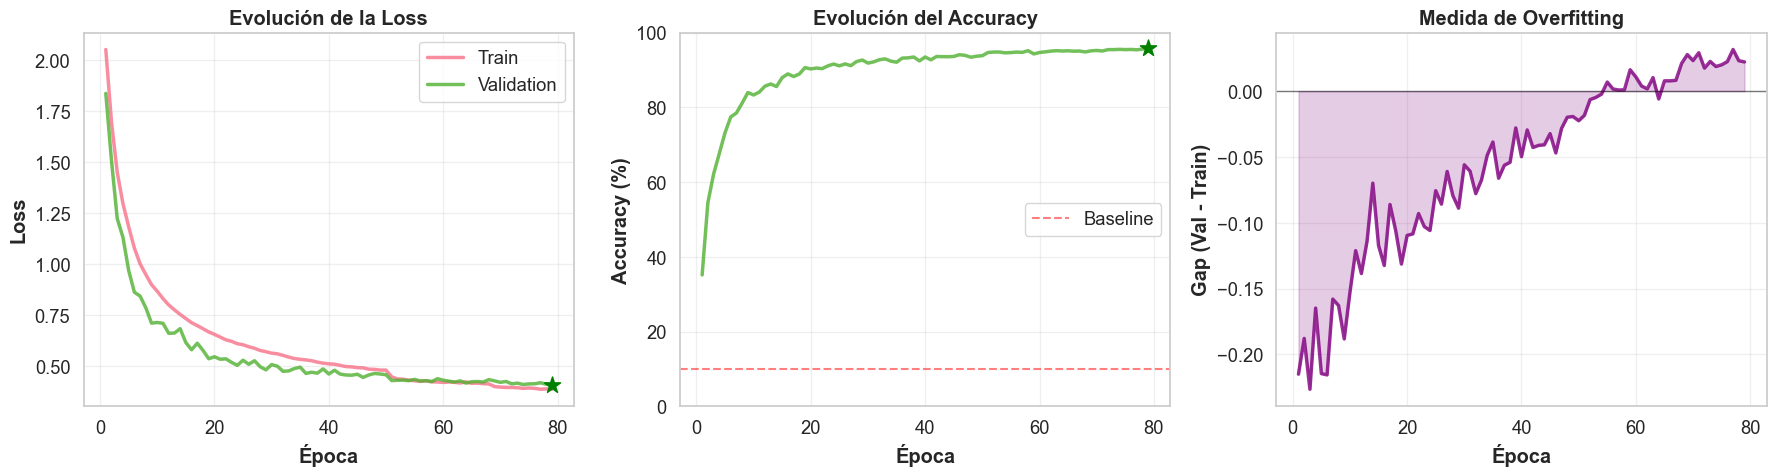

In [22]:
# ==============================================================================
# VISUALIZACIÓN DE CURVAS DE ENTRENAMIENTO
# ==============================================================================

pipeline.plot_training_curves()

## 3.4 Comparación de resultados con modelos anteriores

In [23]:
summary = pipeline.summarize_experiments(sort_by="results.best_val_acc", top_k=5)


=== RESUMEN DE EXPERIMENTOS ===
                                  id                  timestamp                                           name device  epochs  best_epoch  best_val_acc  final_val_acc  min_val_loss  final_val_loss       lr optimizer
8705cedd-ab2a-497a-89ac-489960c190eb 2025-11-25T02:57:42.514354 ResNet(9-9-9)-AdamW-autoaug-lrschedconstraints    mps      79          79        0.9581         0.9581      0.410264        0.410264 0.000125     AdamW


## 4. Evaluación sobre nuevos datos -> SOLAMENTE EN EL MEJOR MODELO

A continuación les dejamos código que les permite abrir una serie de imágenes nuevas sobre las que podrían validar el algoritmo que implementaron.

Tienen que desarrollar las rutinas necesarias para:
* Convertir estas imágenes a tensores con los tamaños adecuados para poder procesarlos.
* Normalizarlos (utilizando las estadísticas que calculamos sobre los datos de entrenamiento).
* Iterar imagen por imagen y obtener su etiqueta utilizando la red neuronal convolucional entrenada.
* Calcular una o varias métricas de evaluación.
* Mostrar algunos ejemplos de resultados correctos o errados.

In [24]:
# ==============================================================================
# CARGA DE DATOS CIFAR-10.1
# ==============================================================================

# Cargar datos
images = np.load(path.join(new_datasets_folder, 'cifar10.1_v4_data.npy'))
labels = np.load(path.join(new_datasets_folder, 'cifar10.1_v4_labels.npy'))

print("="*70)
print("CIFAR-10.1 DATASET")
print("="*70)
print(f"Shape de imágenes: {images.shape}")
print(f"Shape de labels: {labels.shape}")
print(f"Total de imágenes de test: {len(images)}")
print("="*70)

CIFAR-10.1 DATASET
Shape de imágenes: (2021, 32, 32, 3)
Shape de labels: (2021,)
Total de imágenes de test: 2021


In [25]:
from torch.utils.data import Dataset

class Cifar101Dataset(Dataset):
    def __init__(self, images, labels, transforms=None):
        self.images = images
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transforms:
            image = self.transforms(image)

        return image, label


test_dataset = Cifar101Dataset(images, labels, test_transformations)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


EVALUACIÓN EN CIFAR-10.1

Accuracy en CIFAR-10.1: 89.86%
   Correctas: 1816/2021

ACCURACY POR CLASE
  airplane    : 84.13%  ( 208 samples)
  automobile  : 84.91%  ( 212 samples)
  bird        : 90.59%  ( 202 samples)
  cat         : 86.32%  ( 212 samples)
  deer        : 94.61%  ( 204 samples)
  dog         : 86.24%  ( 218 samples)
  frog        : 92.19%  ( 192 samples)
  horse       : 92.38%  ( 210 samples)
  ship        : 93.17%  ( 161 samples)
  truck       : 95.54%  ( 202 samples)

4. Generando matriz de confusión...


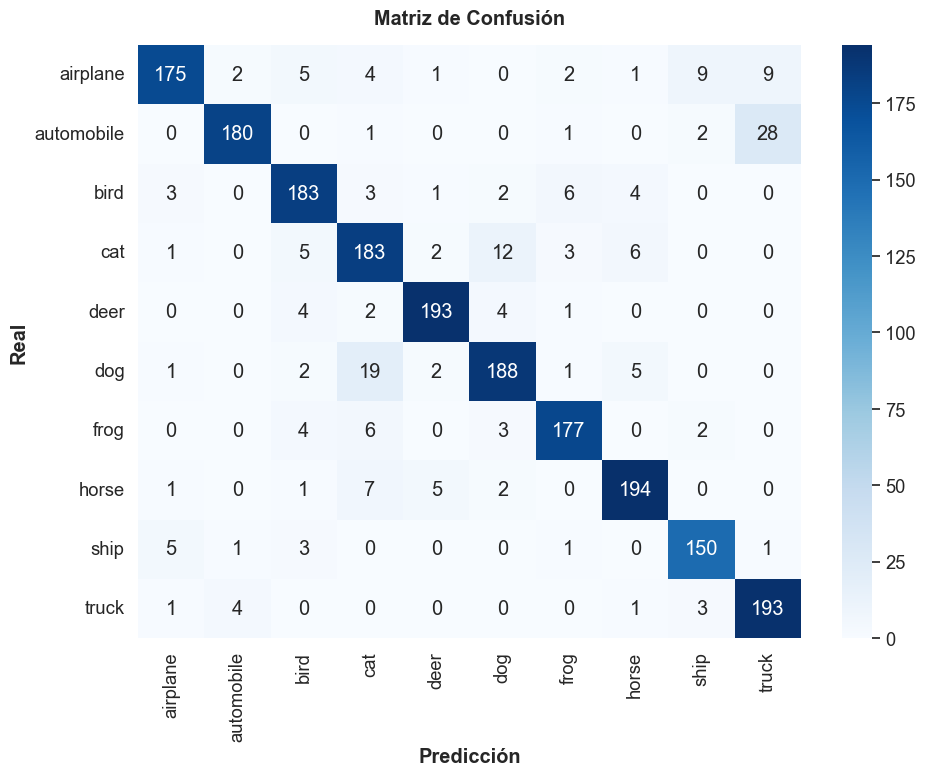


5. Mostrando ejemplos de predicciones...


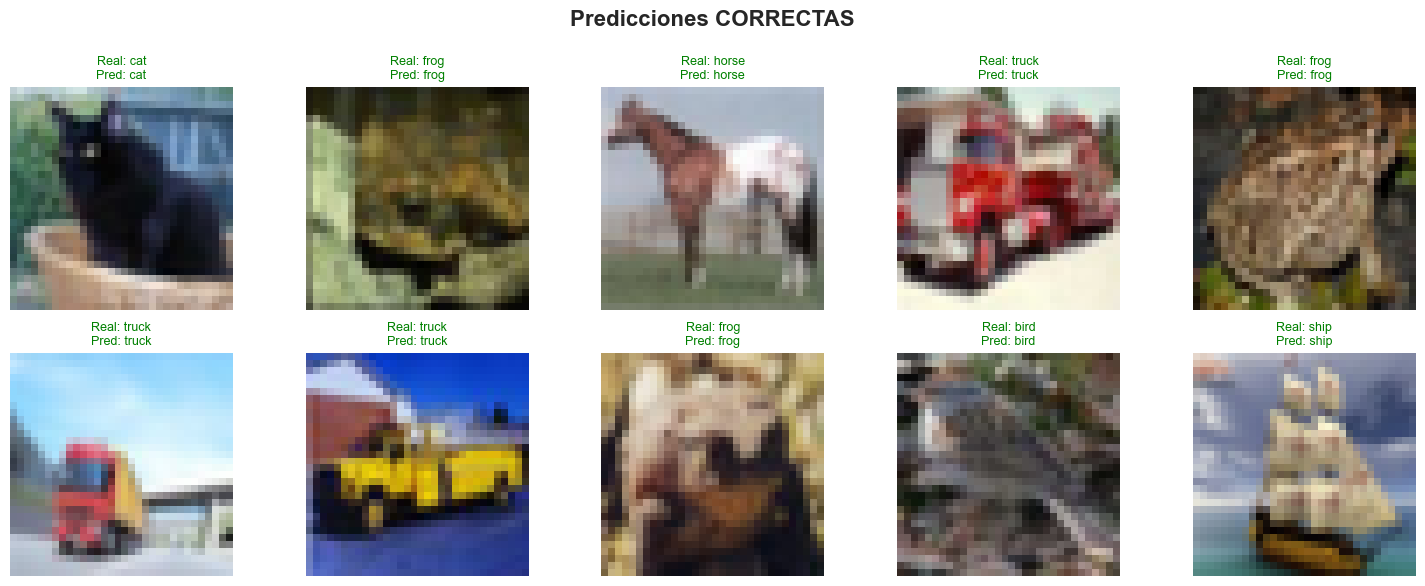

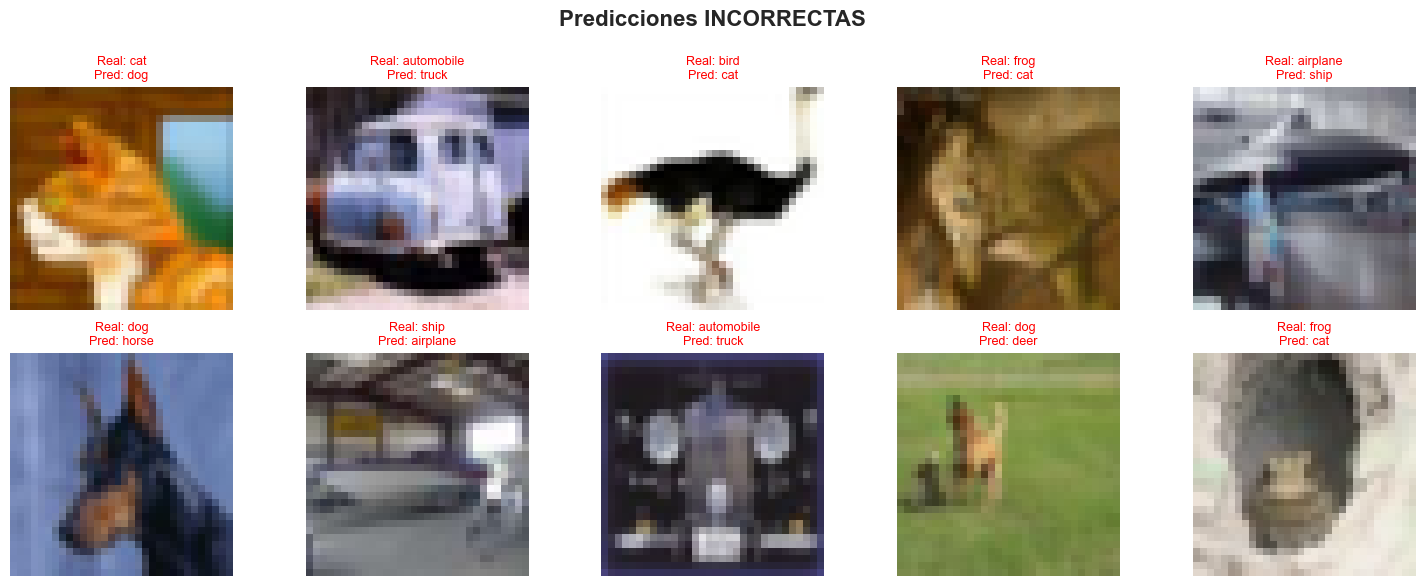


EVALUACIÓN COMPLETADA


In [26]:
# ==============================================================================
# EVALUACIÓN COMPLETA EN CIFAR-10.1
# ==============================================================================

# 2. Evaluar con el pipeline
results = pipeline.evaluate(test_dataloader, dataset_name="CIFAR-10.1")

# 3. Accuracy por clase
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\n" + "="*70)
print("ACCURACY POR CLASE")
print("="*70)
for i, class_name in enumerate(class_names):
    mask = labels == i
    if mask.sum() > 0:
        class_acc = (results['predictions'][mask] == labels[mask]).sum() / mask.sum()
        print(f"  {class_name:12s}: {class_acc:6.2%}  ({mask.sum():4d} samples)")
print("="*70)

# 4. Matriz de confusión
print("\n4. Generando matriz de confusión...")
pipeline.plot_confusion_matrix(results['predictions'], results['labels'], class_names)

# 5. Ejemplos visuales
print("\n5. Mostrando ejemplos de predicciones...")

# Sacamos todas las imágenes del dataset normalizadas
images_plot = []
for img, label in test_dataset:
    images_plot.append(img)

images_plot = np.stack(images_plot)

pipeline.plot_examples(images_plot, results['predictions'], results['labels'],
                      class_names, mean, std, n_correct=10, n_incorrect=10)

print("\n" + "="*70)
print("EVALUACIÓN COMPLETADA")
print("="*70)